<a href="https://colab.research.google.com/github/Shivappa/AL-ML-CO2-Emission/blob/main/co2emission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CO2 Emissions Analysis - Business Case Study

# 1. Data Import and Initial Exploration

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression

In [6]:
# Load the data set
df = pd.read_csv('CO2_Emissions.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [12]:
df.shape

(7385, 12)

In [7]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [8]:
df.tail()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7384,VOLVO,XC90 T6 AWD,SUV - STANDARD,2.0,4,AS8,Z,12.2,8.7,10.7,26,248


# 2. Data Cleaning

In [13]:
# Check if there are any missing data
missing_data = df.isnull().sum()
missing_data

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


In [14]:
# Check any duplicate data
duplicate_data = df.duplicated().sum()
duplicate_data

np.int64(1103)

In [16]:
# Remove the duplicates
df_cleaned = df.drop_duplicates()
df_cleaned.shape


(7385, 12)

In [32]:
df_final = df_cleaned.copy()
# Target column
target_column = 'CO2 Emissions(g/km)'

# 3. Exploratory Data Analysis (EDA)

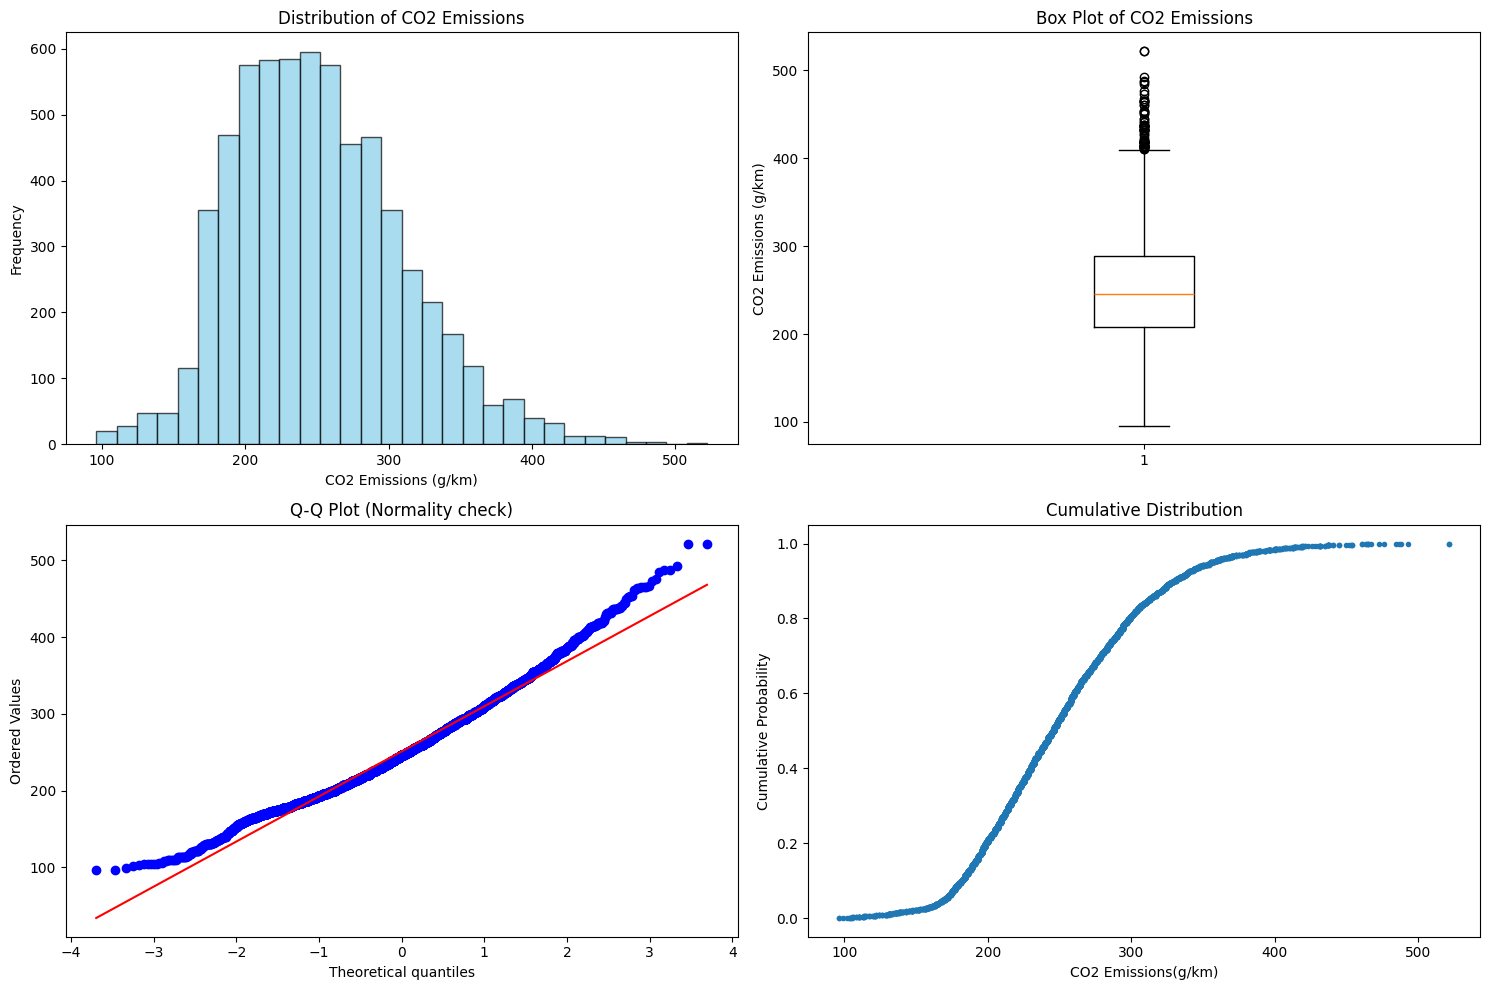

In [34]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Histogram
axes[0,0].hist(df_final[target_column], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2 Emissions (g/km)')
axes[0,0].set_ylabel('Frequency')

# Box plot
axes[0,1].boxplot(df_final[target_column])
axes[0,1].set_title('Box Plot of CO2 Emissions')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')

# Quantile-Quantile plot for normality
stats.probplot(df_final[target_column], dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality check)')

# Cumulative distribution
sorted_values = np.sort(df_final[target_column])
y = np.arange(1, len(sorted_values)+1) / len(sorted_values)
axes[1,1].plot(sorted_values, y, marker='.', linestyle='none')
axes[1,1].set_title('Cumulative Distribution')
axes[1,1].set_xlabel(target_column)
axes[1,1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()

In [41]:
# Get the Mean, Median, SD and Skewness
mean = df_final[target_column].mean()
median = df_final[target_column].median()
sd = df_final[target_column].std()
skewness = df_final[target_column].skew()

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Standard Deviation: {sd:.2f}")
print(f"Skewness: {skewness:.2f}")


Mean: 251.16
Median: 246.00
Standard Deviation: 59.29
Skewness: 0.56


In [42]:
# Get categorical variables
categorical_columns = df_final.select_dtypes(include=['object']).columns
categorical_columns

Index(['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type'], dtype='object')

In [43]:
# Get numerical variables
numerical_columns = df_final.select_dtypes(include=['int64', 'float64']).columns
numerical_columns

Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')

# 4. Correlations

In [45]:
# Correlations metrics
correlation_matrix = df_final[numerical_columns].corr()
correlation_matrix

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
Engine Size(L),1.000000,0.928843,0.834228,0.766817,0.820146,-0.762955,0.854802
Cylinders,0.928843,1.000000,0.801277,0.717647,0.781099,-0.723731,0.834687
Fuel Consumption City (L/100 km),0.834228,0.801277,1.000000,0.950811,0.994052,-0.927640,0.918756
Fuel Consumption Hwy (L/100 km),0.766817,0.717647,0.950811,1.000000,0.978607,-0.891892,0.883424
Fuel Consumption Comb (L/100 km),0.820146,0.781099,0.994052,0.978607,1.000000,-0.925801,0.916840
Fuel Consumption Comb (mpg),-0.762955,-0.723731,-0.927640,-0.891892,-0.925801,1.000000,-0.906783
CO2 Emissions(g/km),0.854802,0.834687,0.918756,0.883424,0.916840,-0.906783,1.000000


In [53]:
# Correlations with target variable
target_correlations = correlation_matrix[target_column].sort_values(ascending=False, key=abs)
target_correlations

,CO2 Emissions(g/km)
CO2 Emissions(g/km),1.000000
Fuel Consumption City (L/100 km),0.918756
Fuel Consumption Comb (L/100 km),0.916840
Fuel Consumption Comb (mpg),-0.906783
Fuel Consumption Hwy (L/100 km),0.883424
Engine Size(L),0.854802
Cylinders,0.834687


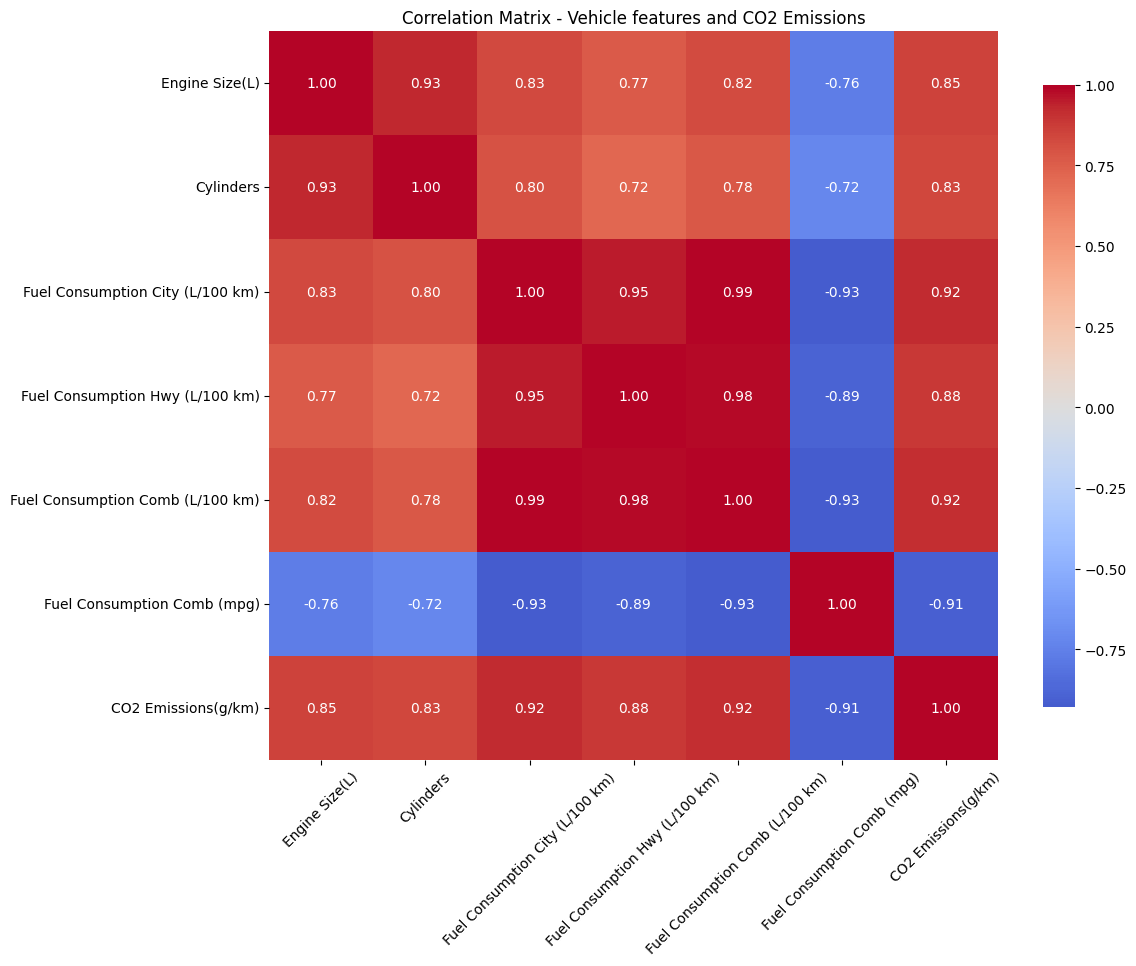

In [50]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
# mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix,
            annot=True,
            # mask=mask,
            cmap='coolwarm',
            fmt='.2f',
            center=0,
            square=True,
            cbar_kws={'shrink':0.8})
plt.title('Correlation Matrix - Vehicle features and CO2 Emissions')

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [54]:
# Identify TOP Predictors .. top 5
top_predictors = target_correlations.drop(target_column).head(5)
top_predictors

,CO2 Emissions(g/km)
Fuel Consumption City (L/100 km),0.918756
Fuel Consumption Comb (L/100 km),0.916840
Fuel Consumption Comb (mpg),-0.906783
Fuel Consumption Hwy (L/100 km),0.883424
Engine Size(L),0.854802


In [51]:
# Statistical Significance tests for correlations

from scipy.stats import pearsonr

significant_correlations = []
for col in numerical_columns:
  if col != target_column:
    corr_coef, p_value = pearsonr(df_final[col], df_final[target_column])
    significance = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'NS'
    significant_correlations.append({'Variable':col,
        'Correlation': corr_coef,
        'P-Value': p_value,
        'Significance': significance
    })
sig_df = pd.DataFrame(significant_correlations).sort_values('Correlation', ascending=False, key=abs)
display(sig_df)

,Variable,Correlation,P-Value,Significance
2,Fuel Consumption City (L/100 km),0.918756,0.0,***
4,Fuel Consumption Comb (L/100 km),0.916840,0.0,***
5,Fuel Consumption Comb (mpg),-0.906783,0.0,***
3,Fuel Consumption Hwy (L/100 km),0.883424,0.0,***
0,Engine Size(L),0.854802,0.0,***
1,Cylinders,0.834687,0.0,***


# 5. Data Visulaization and Pattern Discovery

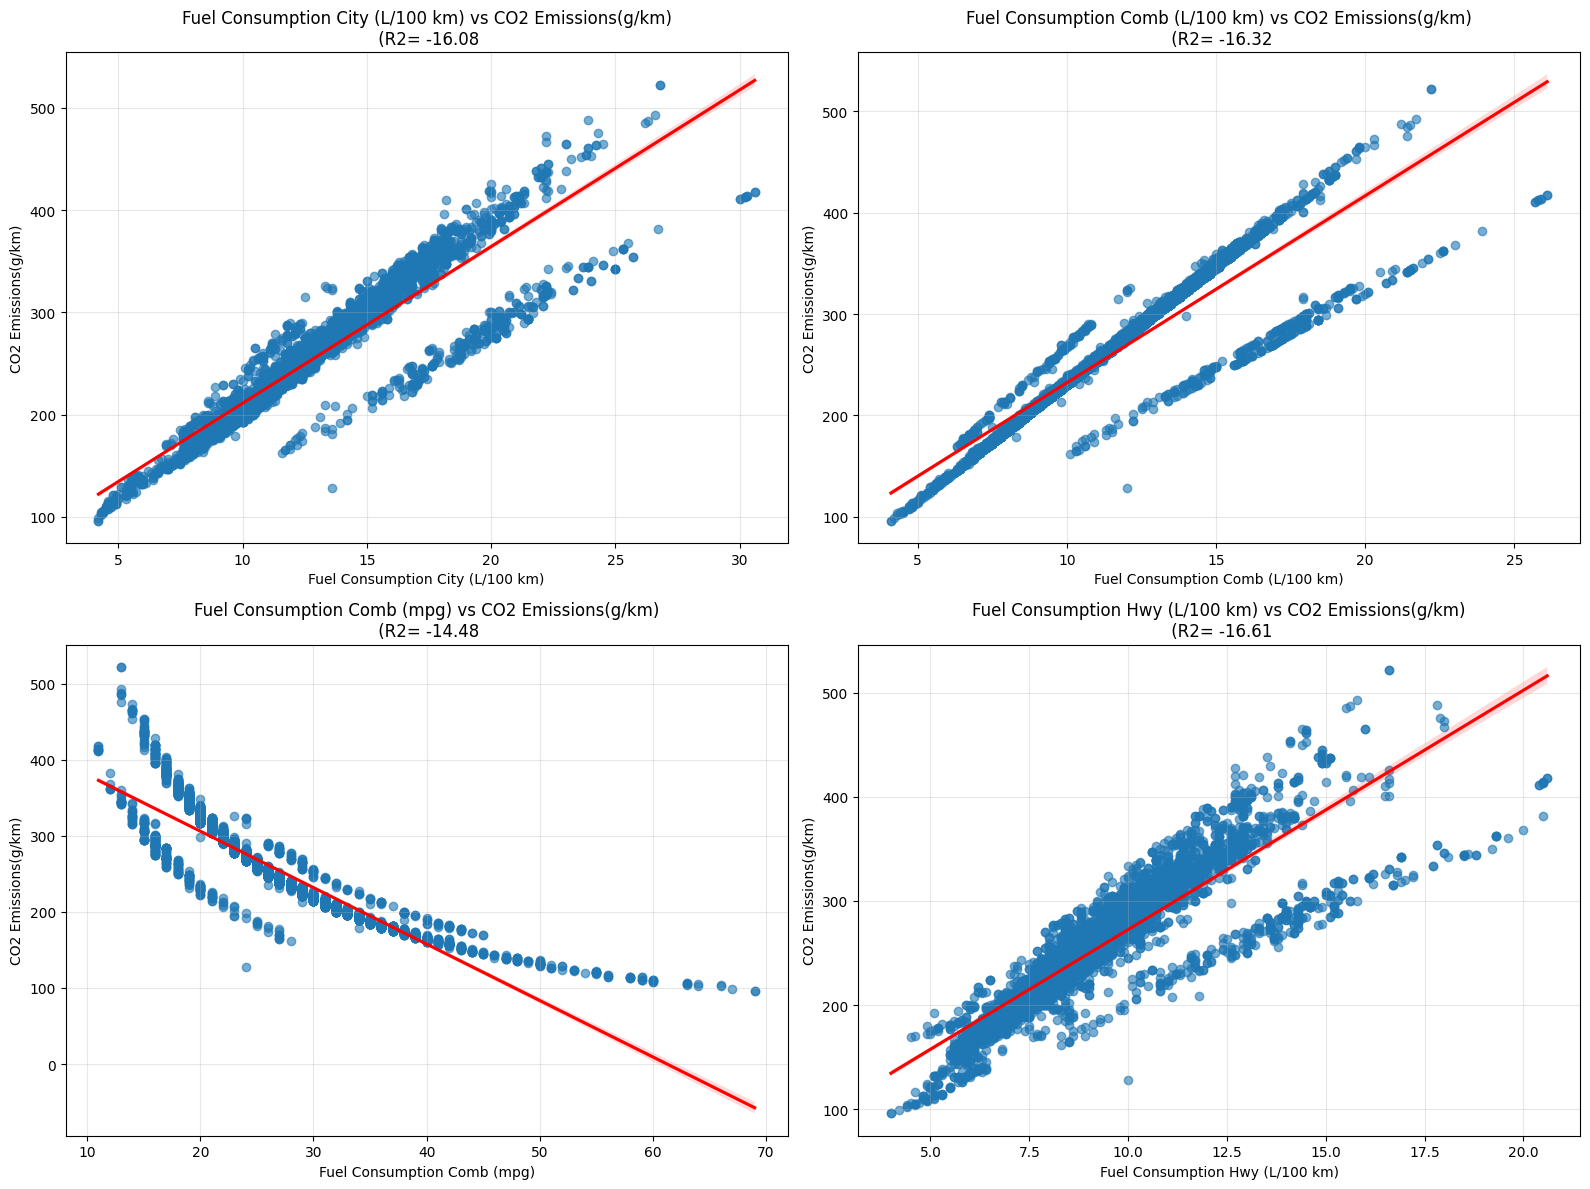

In [55]:
# Scatter plots for top numerical predictors
top_numerical_predictors = [col for col in top_predictors.index[:4] if col in numerical_columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, predictor in enumerate(top_numerical_predictors):
  if i < 4:
    # scatter plot with regression line
    sns.regplot(x=predictor,
                y=target_column,
                data=df_final,
                ax=axes[i],
                scatter_kws={'alpha':0.6},
                line_kws={'color':'red'})
    # Calculate R2 (R2 square)
    r2 = r2_score(df_final[target_column], df_final[predictor])
    axes[i].set_title(f'{predictor} vs {target_column}\n (R2= {r2:.2f}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()₹


# 6. Categorical Analysis and Comparision

In [60]:
# Analyse CO2 Emissions by Categorical Variables
categorical_analysis = {}

for categorical_column in categorical_columns:
  category_stats = df_final.groupby(categorical_column)[target_column].agg(
      ['mean', 'median', 'std', 'count', 'min', 'max']).round(2)
  categorical_analysis[categorical_column] = category_stats

  # I disaplyed only top 5
  display(category_stats.sort_values(by='mean', ascending=False).head(5))



,mean,median,std,count,min,max
Make,,,,,,
BUGATTI,522.00,522.0,0.00,2,522,522
LAMBORGHINI,402.27,384.0,50.32,37,331,493
SRT,389.00,389.0,0.00,2,389,389
ROLLS-ROYCE,388.75,393.0,12.32,48,359,404
BENTLEY,367.91,373.0,41.16,35,291,465


,mean,median,std,count,min,max
Model,,,,,,
Chiron,522.0,522.0,NaN,1,522,522
CHIRON,522.0,522.0,NaN,1,522,522
Aventador Roadster,493.0,493.0,NaN,1,493,493
E350 WAGON,488.0,488.0,NaN,1,488,488
Aventador Coupe,486.0,486.0,1.41,2,485,487


,mean,median,std,count,min,max
Vehicle Class,,,,,,
VAN - PASSENGER,397.21,414.0,42.27,66,315,488
VAN - CARGO,361.50,362.0,17.87,22,334,396
SUV - STANDARD,306.73,306.0,44.30,613,156,476
PICKUP TRUCK - STANDARD,301.61,298.0,31.04,475,238,414
TWO-SEATER,282.09,270.0,75.11,381,145,522


,mean,median,std,count,min,max
Transmission,,,,,,
A7,314.27,291.0,53.26,44,248,473
A10,313.96,325.5,32.13,28,238,357
A5,299.37,299.0,42.63,78,172,488
A4,296.59,344.0,83.91,61,168,421
A8,285.42,286.0,43.11,378,181,413


,mean,median,std,count,min,max
Fuel Type,,,,,,
E,276.05,280.0,48.74,330,128,418
Z,265.73,254.0,57.64,2765,122,522
X,235.98,229.0,58.30,3039,96,488
D,235.24,243.0,41.91,147,169,326
N,213.00,213.0,NaN,1,213,213


# 7. Outlier Detection and Analysis

In [68]:
# Outlier detection using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Outlier detection using Z-score method
def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs(stats.zscore(data[column]))
    outliers = data[z_scores > threshold]
    return outliers

# IQR method
iqr_outliers, lower_bound, upper_bound = detect_outliers_iqr(df_final, target_column)

# Z-score method
zscore_outliers = detect_outliers_zscore(df_final, target_column)


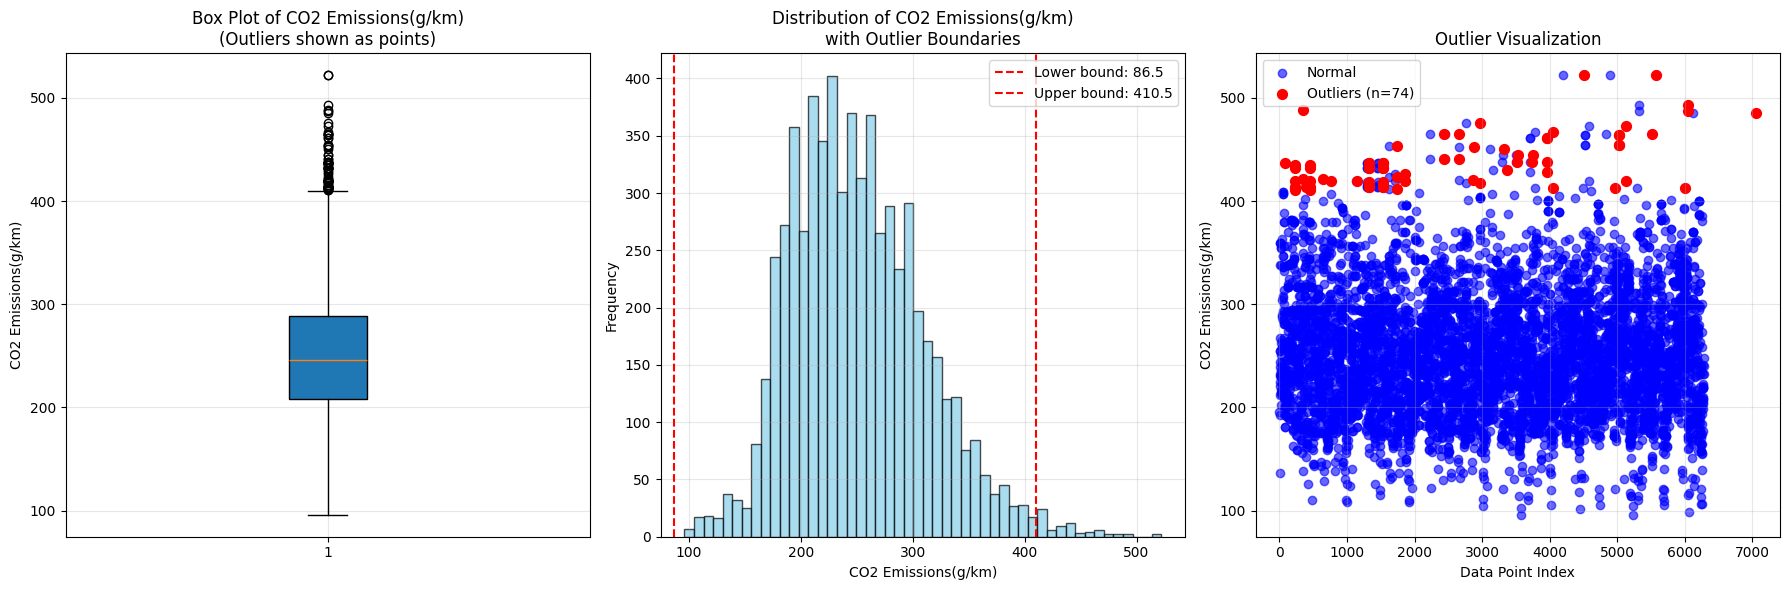

In [69]:
# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Box plot highlighting outliers
axes[0].boxplot(df_final[target_column], patch_artist=True)
axes[0].set_title(f'Box Plot of {target_column}\n(Outliers shown as points)')
axes[0].set_ylabel(target_column)
axes[0].grid(True, alpha=0.3)

# Histogram with outlier boundaries
axes[1].hist(df_final[target_column], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1].axvline(lower_bound, color='red', linestyle='--', label=f'Lower bound: {lower_bound:.1f}')
axes[1].axvline(upper_bound, color='red', linestyle='--', label=f'Upper bound: {upper_bound:.1f}')
axes[1].set_title(f'Distribution of {target_column}\nwith Outlier Boundaries')
axes[1].set_xlabel(target_column)
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Scatter plot showing outliers
axes[2].scatter(range(len(df_final)), df_final[target_column], alpha=0.6, color='blue', label='Normal')
outlier_indices = iqr_outliers.index
axes[2].scatter(outlier_indices, df_final.loc[outlier_indices, target_column],
               color='red', s=50, label=f'Outliers (n={len(outlier_indices)})')
axes[2].set_title('Outlier Visualization')
axes[2].set_xlabel('Data Point Index')
axes[2].set_ylabel(target_column)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Data Preprocessing for Modelling

In [82]:
df_model = df_final.copy()

# Identify features and target
feature_cols = [col for col in df_model.columns if col != target_column]
X = df_model[feature_cols].copy()
y = df_model[target_column].copy()


In [84]:
# Handle categorical variables
categorical_encoders = {}
X_processed = X.copy()

for cat_col in categorical_columns:
    if cat_col in X_processed.columns:

        # Use Label Encoding for simplicity (could use One-Hot Encoding for better results)
        le = LabelEncoder()
        X_processed[cat_col] = le.fit_transform(X_processed[cat_col])
        categorical_encoders[cat_col] = le



# 9. Model Development and Training

,Feature,Importance Score
6,Fuel Consumption City (L/100 km),27416.057907
8,Fuel Consumption Comb (L/100 km),26470.683119
9,Fuel Consumption Comb (mpg),23799.333624
7,Fuel Consumption Hwy (L/100 km),17690.206793
3,Engine Size(L),13606.616725
4,Cylinders,11401.571569
5,Transmission,551.049266
2,Vehicle Class,449.369815
0,Make,109.934053
1,Model,59.759131


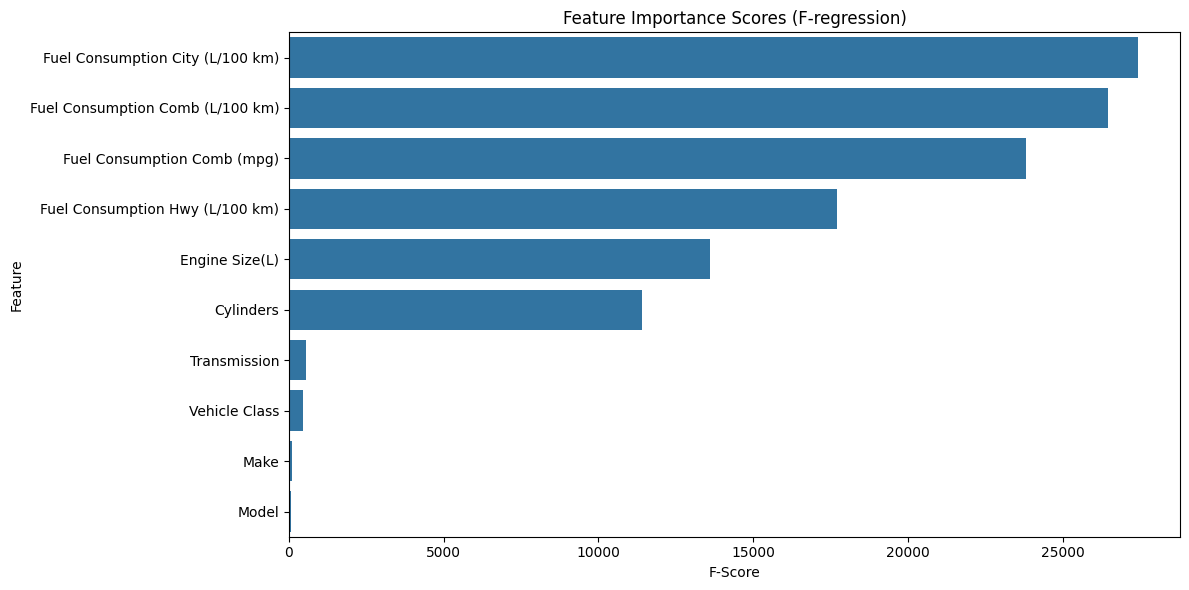

In [85]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X_processed, y, test_size=0.2, random_state=42, stratify=None
)

# Use SelectKBest with f_regression to identify top features
n_features_to_select = min(10, X_train.shape[1])  # Select top 10 or all available features
selector = SelectKBest(score_func=f_regression, k=n_features_to_select)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()].tolist()
feature_scores = selector.scores_[selector.get_support()]

feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance Score': feature_scores
}).sort_values('Importance Score', ascending=False)

display(feature_importance_df)

# Visualize feature importance
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_df, x='Importance Score', y='Feature')
plt.title('Feature Importance Scores (F-regression)')
plt.xlabel('F-Score')
plt.tight_layout()
plt.show()



In [87]:
# TRAIN LINEAR REGRESSION MODEL

# Train model with all features
lr_full = LinearRegression()
lr_full.fit(X_train, y_train)

# Train model with selected features
lr_selected = LinearRegression()
lr_selected.fit(X_train_selected, y_train)

coefficients_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lr_selected.coef_
}).sort_values('Coefficient', ascending=False, key=abs)

display(coefficients_df)

,Feature,Coefficient
4,Cylinders,7.262583
3,Engine Size(L),5.674658
7,Fuel Consumption Hwy (L/100 km),3.885396
9,Fuel Consumption Comb (mpg),-3.344644
6,Fuel Consumption City (L/100 km),3.194615
8,Fuel Consumption Comb (L/100 km),-1.839836
2,Vehicle Class,0.739459
0,Make,0.111751
5,Transmission,0.095042
1,Model,-0.000127


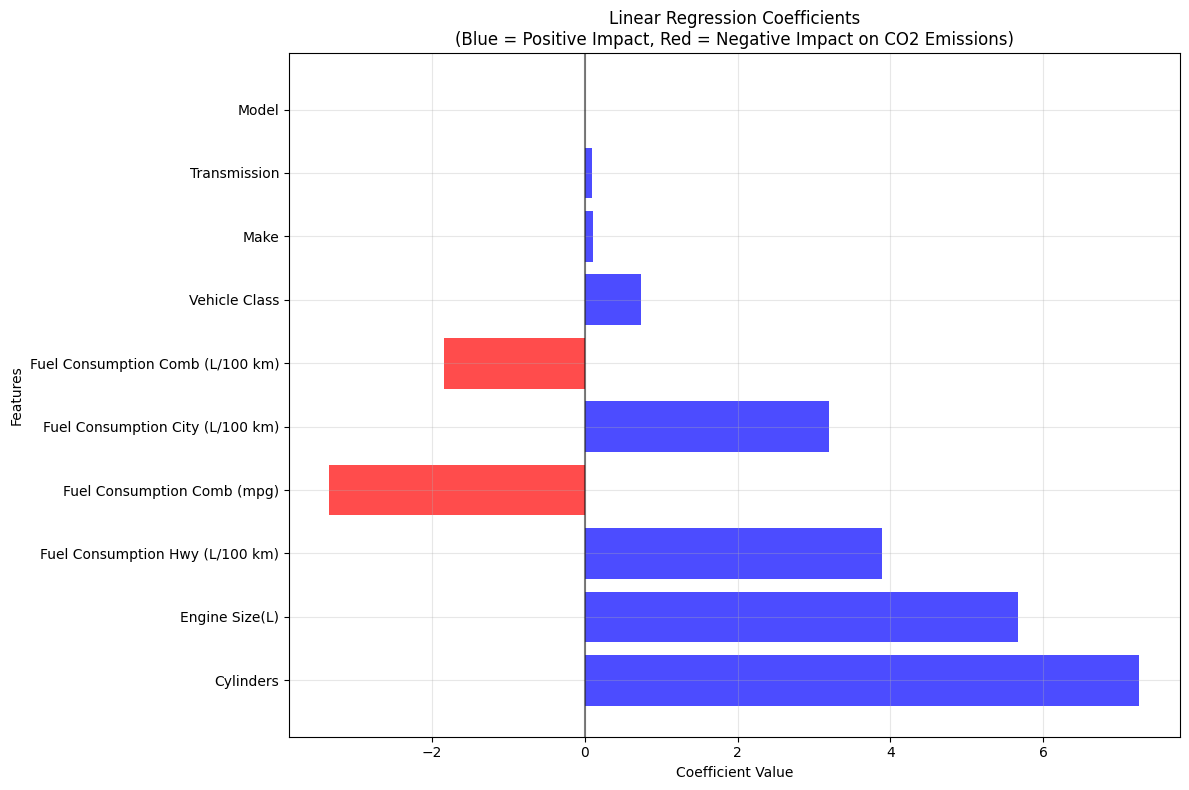

In [88]:
# Visualize model coefficients
plt.figure(figsize=(12, 8))

# Create a horizontal bar plot
colors = ['red' if coef < 0 else 'blue' for coef in coefficients_df['Coefficient']]
plt.barh(coefficients_df['Feature'], coefficients_df['Coefficient'], color=colors, alpha=0.7)

plt.title('Linear Regression Coefficients\n(Blue = Positive Impact, Red = Negative Impact on CO2 Emissions)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10. Model Evaluation and performance Assessment

In [91]:
# Make predictions
y_train_pred_full = lr_full.predict(X_train)
y_test_pred_full = lr_full.predict(X_test)

y_train_pred_selected = lr_selected.predict(X_train_selected)
y_test_pred_selected = lr_selected.predict(X_test_selected)

# Calculate performance metrics
def calculate_metrics(y_true, y_pred, dataset_name, model_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        'Dataset': dataset_name,
        'Model': model_name,
        'R2': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

# Calculate metrics for all models and datasets
metrics_results = []

metrics_results.append(calculate_metrics(y_train, y_train_pred_full, 'Training', 'Full Features'))
metrics_results.append(calculate_metrics(y_test, y_test_pred_full, 'Testing', 'Full Features'))
metrics_results.append(calculate_metrics(y_train, y_train_pred_selected, 'Training', 'Selected Features'))
metrics_results.append(calculate_metrics(y_test, y_test_pred_selected, 'Testing', 'Selected Features'))

metrics_df = pd.DataFrame(metrics_results)

display(metrics_df.round(4))

,Dataset,Model,R2,MAE,MSE,RMSE
0,Training,Full Features,0.9174,11.1269,288.2847,16.9789
1,Testing,Full Features,0.9094,11.9241,326.9686,18.0823
2,Training,Selected Features,0.9074,11.5816,323.2523,17.9792
3,Testing,Selected Features,0.9027,12.1690,351.0050,18.7351


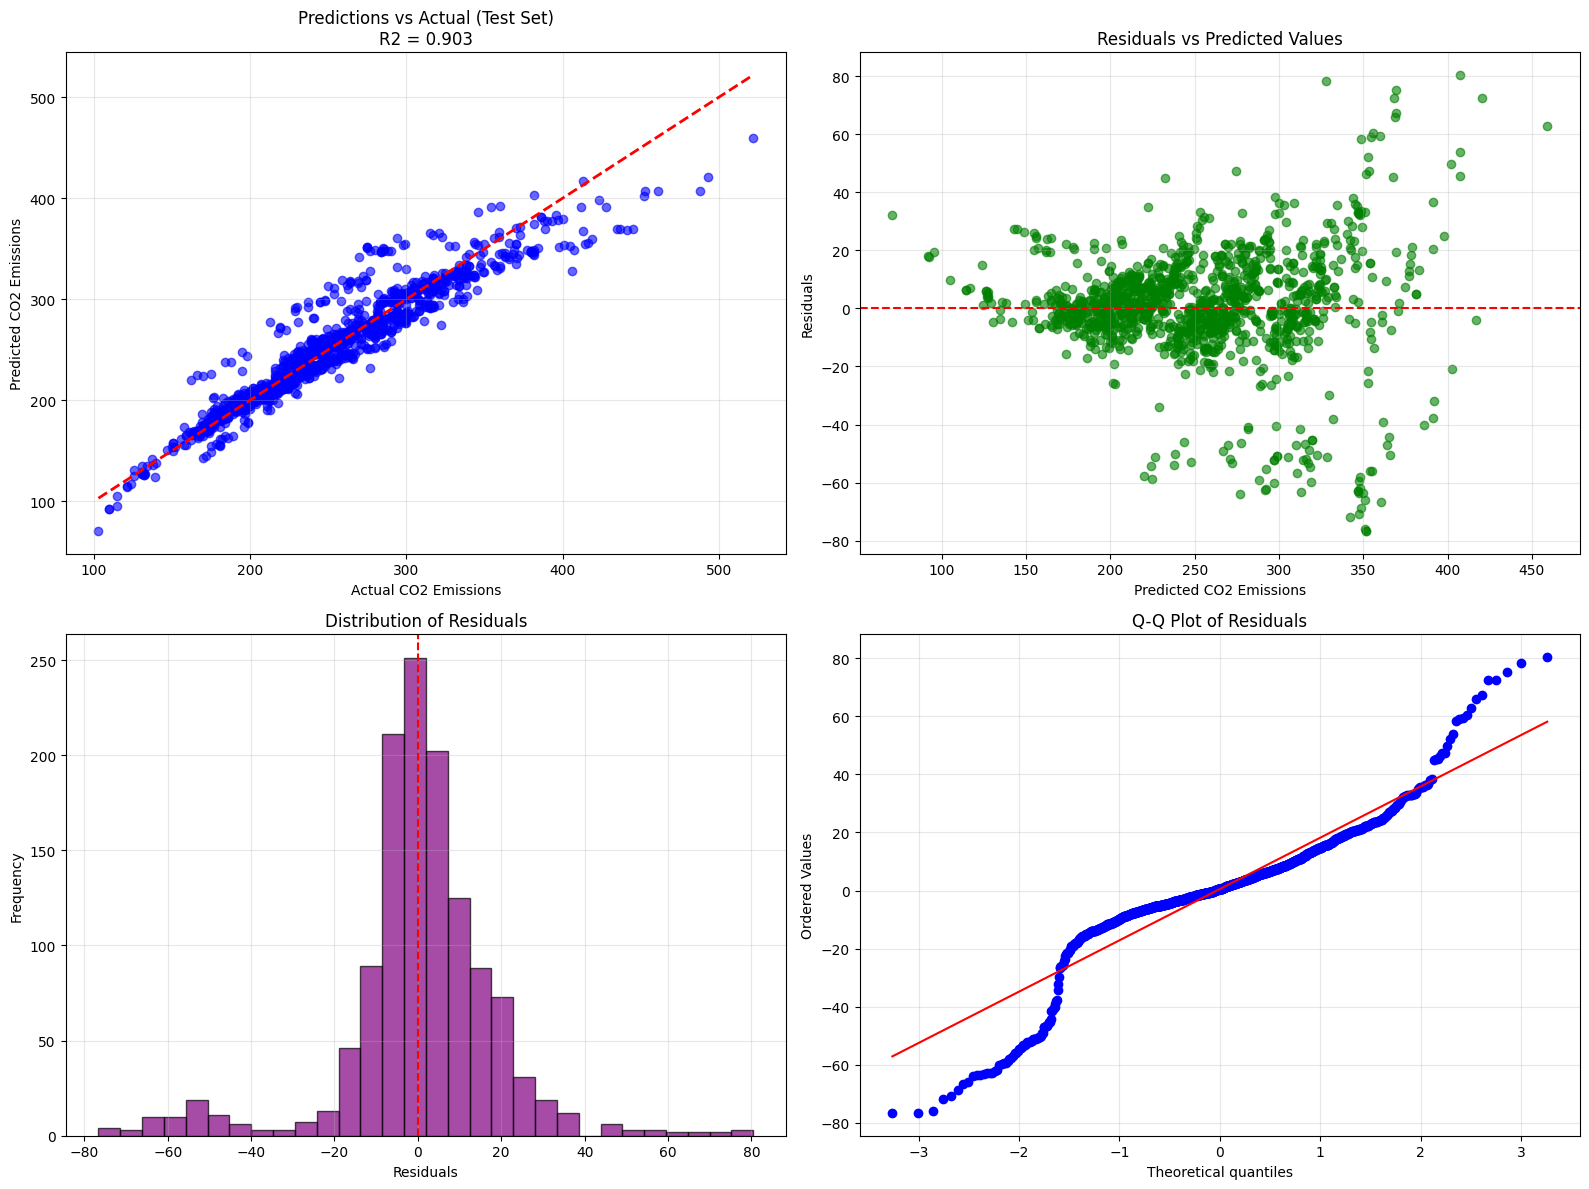

In [93]:
# Visualize model performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Predictions vs Actual for Selected Features Model (Test Set)
axes[0,0].scatter(y_test, y_test_pred_selected, alpha=0.6, color='blue')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual CO2 Emissions')
axes[0,0].set_ylabel('Predicted CO2 Emissions')
axes[0,0].set_title(f'Predictions vs Actual (Test Set)\nR2 = {r2_score(y_test, y_test_pred_selected):.3f}')
axes[0,0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_test_pred_selected
axes[0,1].scatter(y_test_pred_selected, residuals, alpha=0.6, color='green')
axes[0,1].axhline(y=0, color='red', linestyle='--')
axes[0,1].set_xlabel('Predicted CO2 Emissions')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals vs Predicted Values')
axes[0,1].grid(True, alpha=0.3)

# Distribution of residuals
axes[1,0].hist(residuals, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Residuals')
axes[1,0].axvline(x=0, color='red', linestyle='--')
axes[1,0].grid(True, alpha=0.3)

# Q-Q plot for residuals
stats.probplot(residuals, dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot of Residuals')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_172/3232422613.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


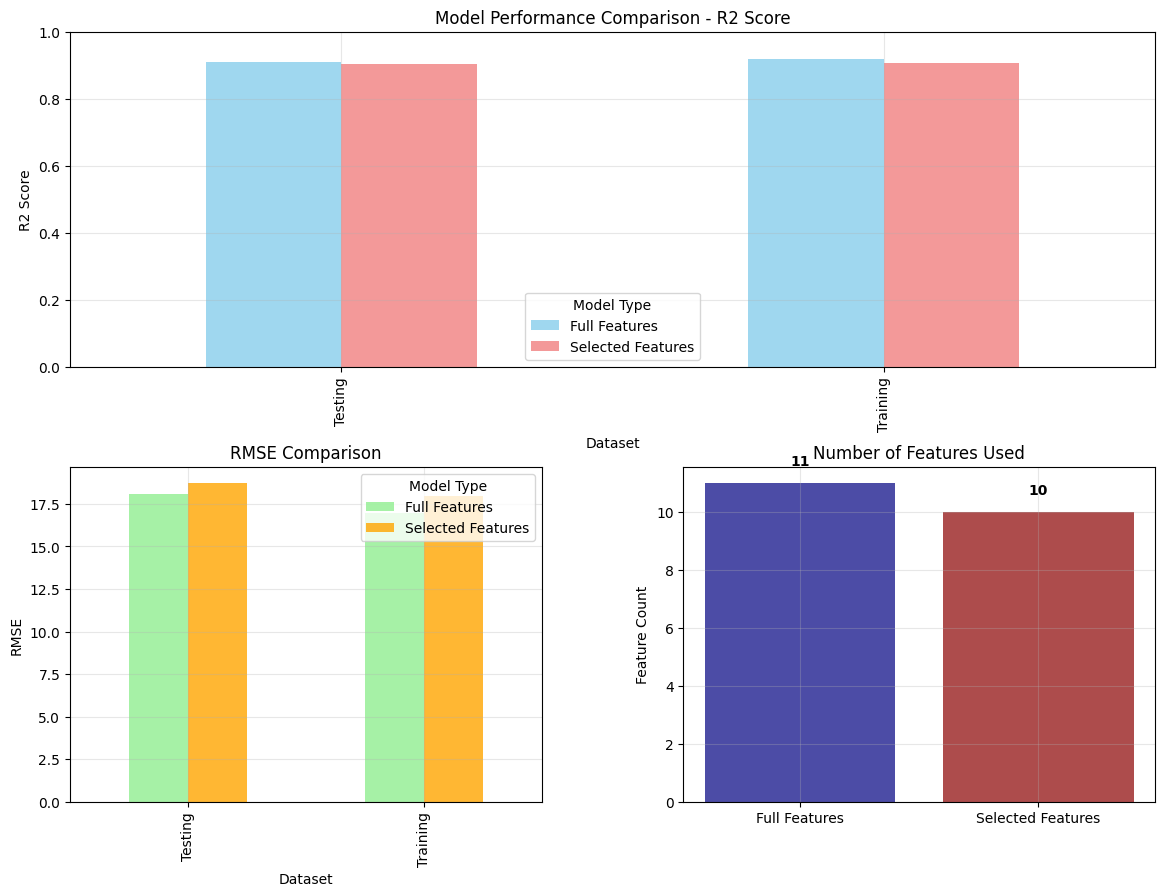

In [95]:
# Compare model performance visually
plt.figure(figsize=(14, 10))

# Create subplots for comparison
gs = plt.GridSpec(2, 2, hspace=0.3, wspace=0.3)

# R2 comparison
ax1 = plt.subplot(gs[0, :])
r2_data = metrics_df.pivot(index='Dataset', columns='Model', values='R2')
r2_data.plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'], alpha=0.8)
ax1.set_title('Model Performance Comparison - R2 Score')
ax1.set_ylabel('R2 Score')
ax1.set_ylim(0, 1)
ax1.legend(title='Model Type')
ax1.grid(True, alpha=0.3)

# RMSE comparison
ax2 = plt.subplot(gs[1, 0])
rmse_data = metrics_df.pivot(index='Dataset', columns='Model', values='RMSE')
rmse_data.plot(kind='bar', ax=ax2, color=['lightgreen', 'orange'], alpha=0.8)
ax2.set_title('RMSE Comparison')
ax2.set_ylabel('RMSE')
ax2.legend(title='Model Type')
ax2.grid(True, alpha=0.3)

# Feature count comparison
ax3 = plt.subplot(gs[1, 1])
feature_counts = [X_train.shape[1], len(selected_features)]
model_names = ['Full Features', 'Selected Features']
ax3.bar(model_names, feature_counts, color=['navy', 'darkred'], alpha=0.7)
ax3.set_title('Number of Features Used')
ax3.set_ylabel('Feature Count')
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(feature_counts):
    ax3.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [100]:
# Model selection recommendation
print("Model Selection Recommendation:")
print("="*35)
test_r2_full = metrics_df[(metrics_df['Dataset'] == 'Testing') & (metrics_df['Model'] == 'Full Features')]['R2'].iloc[0]
test_r2_selected = metrics_df[(metrics_df['Dataset'] == 'Testing') & (metrics_df['Model'] == 'Selected Features')]['R2'].iloc[0]

print(f"Full Features Model - Test R2: {test_r2_full:.4f}")
print(f"Selected Features Model - Test R2: {test_r2_selected:.4f}")
print(f"Performance difference: {abs(test_r2_full - test_r2_selected):.4f}")

if abs(test_r2_full - test_r2_selected) < 0.02:  # Similar performance
    print(f"\n✅ Recommended: Selected Features Model")
    print(f"   Reason: Similar performance with fewer features (better interpretability)")
    final_model = lr_selected
    final_features = selected_features
else:
    if test_r2_full > test_r2_selected:
        print(f"\n✅ Recommended: Full Features Model")
        print(f"   Reason: Significantly better performance")
        final_model = lr_full
        final_features = list(X_train.columns)
    else:
        print(f"\n✅ Recommended: Selected Features Model")
        print(f"   Reason: Better performance with fewer features")
        final_model = lr_selected
        final_features = selected_features

Model Selection Recommendation:
Full Features Model - Test R2: 0.9094
Selected Features Model - Test R2: 0.9027
Performance difference: 0.0067

✅ Recommended: Selected Features Model
   Reason: Similar performance with fewer features (better interpretability)


# 11. Business Insights and Recommendations

In [97]:
# Summarize key findings
print("KEY FINDINGS SUMMARY")
print("="*50)

# 1. Data Overview
print(f"\n1. DATASET OVERVIEW:")
print(f"   • Total vehicles analyzed: {df_final.shape[0]:,}")
print(f"   • Features examined: {df_final.shape[1]}")
print(f"   • CO2 emissions range: {df_final[target_column].min():.1f} - {df_final[target_column].max():.1f}")
print(f"   • Average CO2 emissions: {df_final[target_column].mean():.1f}")

# 2. Top predictors
print(f"\n2. STRONGEST PREDICTORS OF CO2 EMISSIONS:")
final_importance = feature_importance_df.head(5)
for i, row in final_importance.iterrows():
    print(f"   • {row['Feature']}: Importance Score {row['Importance Score']:.1f}")

# 3. Correlations
print(f"\n3. CORRELATION INSIGHTS:")
strongest_corr = target_correlations.drop(target_column).iloc[0]
print(f"   • Strongest correlation: {strongest_corr.name} (r = {strongest_corr:.3f})")

# 4. Model performance
print(f"\n4. MODEL PERFORMANCE:")
final_test_r2 = metrics_df[(metrics_df['Dataset'] == 'Testing') &
                          (metrics_df['Model'] == 'Selected Features')]['R²'].iloc[0]
final_test_rmse = metrics_df[(metrics_df['Dataset'] == 'Testing') &
                           (metrics_df['Model'] == 'Selected Features')]['RMSE'].iloc[0]
print(f"   • Model explains {final_test_r2*100:.1f}% of CO2 emission variance")
print(f"   • Average prediction error: ±{final_test_rmse:.1f} units")

# 5. Categorical insights
print(f"\n5. CATEGORICAL INSIGHTS:")
for cat_col in categorical_columns:
    if cat_col in categorical_analysis:
        stats_data = categorical_analysis[cat_col]
        highest_cat = stats_data['mean'].idxmax()
        lowest_cat = stats_data['mean'].idxmin()
        print(f"   • {cat_col}:")
        print(f"     - Highest emissions: {highest_cat} ({stats_data.loc[highest_cat, 'mean']:.1f})")
        print(f"     - Lowest emissions: {lowest_cat} ({stats_data.loc[lowest_cat, 'mean']:.1f})")

KEY FINDINGS SUMMARY

1. DATASET OVERVIEW:
   • Total vehicles analyzed: 6,282
   • Features examined: 12
   • CO2 emissions range: 96.0 - 522.0
   • Average CO2 emissions: 251.2

2. STRONGEST PREDICTORS OF CO2 EMISSIONS:
   • Fuel Consumption City (L/100 km): Importance Score 27416.1
   • Fuel Consumption Comb (L/100 km): Importance Score 26470.7
   • Fuel Consumption Comb (mpg): Importance Score 23799.3
   • Fuel Consumption Hwy (L/100 km): Importance Score 17690.2
   • Engine Size(L): Importance Score 13606.6

3. CORRELATION INSIGHTS:


AttributeError: 'numpy.float64' object has no attribute 'name'

In [102]:
# Business recommendations
print("BUSINESS RECOMMENDATIONS")
print("="*50)

print(f"\n🎯 FOR AUTOMOTIVE MANUFACTURERS:")
print(f"="*35)

# Based on coefficient analysis
positive_impact = coefficients_df[coefficients_df['Coefficient'] > 0].head(3)
negative_impact = coefficients_df[coefficients_df['Coefficient'] < 0].head(3)

if len(positive_impact) > 0:
    print(f"\n1. REDUCE HIGH-IMPACT FACTORS:")
    for _, row in positive_impact.iterrows():
        print(f"   • Optimize {row['Feature']} - each unit increase adds {row['Coefficient']:.2f} emission units")

if len(negative_impact) > 0:
    print(f"\n2. LEVERAGE EMISSION-REDUCING FACTORS:")
    for _, row in negative_impact.iterrows():
        print(f"   • Enhance {row['Feature']} - each unit increase reduces {abs(row['Coefficient']):.2f} emission units")

print(f"\n3. DESIGN OPTIMIZATION PRIORITIES:")
print(f"   • Focus R&D on the top {len(final_features)} identified key factors")
print(f"   • Target vehicles with characteristics similar to low-emission outliers")
print(f"   • Benchmark against best-performing categories identified in analysis")

print(f"\n🏛️ FOR POLICYMAKERS:")
print(f"="*20)
print(f"1. EMISSION STANDARDS:")
print(f"   • Set progressive targets based on vehicle categories")
print(f"   • Current average: {df_final[target_column].mean():.1f}, target 25th percentile: {df_final[target_column].quantile(0.25):.1f}")

print(f"\n2. INCENTIVE PROGRAMS:")
print(f"   • Provide incentives for vehicles in lowest-emission categories")
print(f"   • Penalize vehicles exceeding {df_final[target_column].quantile(0.75):.1f} emission threshold")

print(f"\n3. MONITORING FRAMEWORK:")
print(f"   • Use this model for emission prediction and verification")
print(f"   • Focus inspections on vehicles predicted to have high emissions")

print(f"\n📊 FOR CONSUMERS:")
print(f"="*15)
emission_categories = pd.qcut(df_final[target_column], q=3, labels=['Low', 'Medium', 'High'])
category_counts = emission_categories.value_counts()

print(f"1. VEHICLE SELECTION GUIDANCE:")
print(f"   • {category_counts['Low']:,} vehicles ({category_counts['Low']/len(df_final)*100:.1f}%) in low-emission category")
print(f"   • Choose vehicles with characteristics of identified low emitters")
print(f"   • Avoid vehicle types identified as high emitters in categorical analysis")

BUSINESS RECOMMENDATIONS

🎯 FOR AUTOMOTIVE MANUFACTURERS:

1. REDUCE HIGH-IMPACT FACTORS:
   • Optimize Cylinders - each unit increase adds 7.26 emission units
   • Optimize Engine Size(L) - each unit increase adds 5.67 emission units
   • Optimize Fuel Consumption Hwy (L/100 km) - each unit increase adds 3.89 emission units

2. LEVERAGE EMISSION-REDUCING FACTORS:
   • Enhance Fuel Consumption Comb (mpg) - each unit increase reduces 3.34 emission units
   • Enhance Fuel Consumption Comb (L/100 km) - each unit increase reduces 1.84 emission units
   • Enhance Model - each unit increase reduces 0.00 emission units

3. DESIGN OPTIMIZATION PRIORITIES:
   • Focus R&D on the top 10 identified key factors
   • Target vehicles with characteristics similar to low-emission outliers
   • Benchmark against best-performing categories identified in analysis

🏛️ FOR POLICYMAKERS:
1. EMISSION STANDARDS:
   • Set progressive targets based on vehicle categories
   • Current average: 251.2, target 25th p